In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd ..

/mnt/c/Codes/boedge1


# Synthetic Experiments
- BA graph ws grid: 100 nodes
- all the kernels
- Plot r-1
- Plot validation error plot

In [3]:
# test the GP cross validation
from problems import get_synthetic_problem
import torch
from search.trust_region import (
    restart,
)
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random

from search.utils import eigendecompose_laplacian
from search.models import initialize_model
from scipy.stats import spearmanr
from tqdm._tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

/tmp/ipykernel_846/1119544288.py:16: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.std.*` instead of `tqdm._tqdm.*`
  from tqdm._tqdm import tqdm


### Define Problems and Models

In [4]:
### Define graph
def output_graph(graph_type, n=200):
    # graph_type = grid, ba, ws
    base_problem = get_synthetic_problem(
        "test_function", 
        n=n, 
        seed=0,
        problem_kwargs={
            "log": False, 
            "random_graph_type": graph_type,
            "m": 1,
            "k": 5,
            "p": 0.1,
            "n": n,
            "test_function": "sphere"}
        )

    X_train = torch.empty(0,1)
    Y_train = torch.empty(0,1)
    base_model, base_mll, based_cached_eigenbasis = initialize_model(
                    train_X=X_train,
                    train_Y=Y_train,
                    context_graph=base_problem.context_graph,
                    covar_type="diffusion",
                    covar_kwargs = {"order": 1},
                    fit_model=False,
                    ard=True,
                    use_fixed_noise=False,
                    use_saas_map=False)

    pos = nx.kamada_kawai_layout(base_problem.context_graph)
    return base_problem, base_model, base_mll, based_cached_eigenbasis, pos

### Define Signals 

In [5]:
# synthetic weighted eigenvector function
def weighted_eigenvector(base_model, j_list, weight_list):
    def eigenvector_function(j):
        return base_model.covar_module.base_kernel.eigenbasis[:,j].detach().clone()
    #__import__('pdb').set_trace()
    all_Y_node_full = torch.tensor([i.tolist() for i in map(eigenvector_function, j_list)])
    res = np.matmul(all_Y_node_full.T, weight_list)
    return res

In [6]:
# Define signal on edges
def get_signal_edge(base_problem, base_model, j=2, split_ratio=0.5, weight_list=None):
    edge_list = torch.tensor([list(i) for i in base_problem.context_graph.edges])
    #all_edges = torch.arange(len(edge_list))
    #all_X = torch.arange(len(base_problem.context_graph)).to(torch.float)
    if weight_list is not None:
        all_Y_node = weighted_eigenvector(base_model, j_list, weight_list)
    else:
        all_Y_node = base_model.covar_module.base_kernel.eigenbasis[:,j].detach().clone()

    
    #__import__('pdb').set_trace()
    # We take the mean of y values on two nodes as the function value of the edge between them.
    all_Y_edge = torch.mean(all_Y_node[edge_list], 1)
    
    from botorch.utils.transforms import standardize

    # Y = base_problem(X.reshape(-1, 1))
    Y = all_Y_edge.reshape(-1, 1).to(dtype=torch.float).detach().clone()
    Y = standardize(Y)
    edge_list = edge_list.to(torch.float)
    
    best_loc = Y.argmax().item()
    X_best = edge_list[best_loc]
    
    n_init = len(edge_list)
    prop_data = split_ratio    
    n_train = int(n_init * prop_data)
    ntrain_indices = np.random.choice(n_init, n_train, replace=False)
    ntest_indices = np.array([i for i in range(n_init) if i not in ntrain_indices])
    X_train, Y_train = edge_list[ntrain_indices], Y[ntrain_indices]
    X_test, Y_test = edge_list[ntest_indices], Y[ntest_indices]
    pos = nx.kamada_kawai_layout(base_problem.context_graph)
    #__import__('pdb').set_trace()
    return edge_list, all_Y_edge, X_train, Y_train, X_test, Y_test, X_best

def get_signal_edge_noise(base_problem, base_model, j=2, split_ratio=0.5, sigma=0.1, weight_list=None):
    edge_list = torch.tensor([list(i) for i in base_problem.context_graph.edges])
    #all_edges = torch.arange(len(edge_list))
    #all_X = torch.arange(len(base_problem.context_graph)).to(torch.float)
    
    if weight_list is not None:
        all_Y_node = weighted_eigenvector(base_model, j_list, weight_list)
    else:
        all_Y_node = base_model.covar_module.base_kernel.eigenbasis[:,j].detach().clone()
    
    all_Y_node += torch.tensor(np.random.normal(scale=sigma, size = all_Y_node.shape))

    #all_Y = base_problem(all_X.reshape(-1, 1))
    
    # We take the mean of y values on two nodes
    all_Y_edge = torch.mean(all_Y_node[edge_list], 1)
    
    from botorch.utils.transforms import standardize

    # Y = base_problem(X.reshape(-1, 1))
    Y = all_Y_edge.reshape(-1, 1).to(dtype=torch.float).detach().clone()
    Y = standardize(Y)
    edge_list = edge_list.to(torch.float)

    best_loc = Y.argmax().item()
    X_best = edge_list[best_loc]
    
    n_init = len(edge_list)
    prop_data = split_ratio    
    n_train = int(n_init * prop_data)
    ntrain_indices = np.random.choice(n_init, n_train, replace=False)
    ntest_indices = np.array([i for i in range(n_init) if i not in ntrain_indices])
    X_train, Y_train = edge_list[ntrain_indices], Y[ntrain_indices]
    X_test, Y_test = edge_list[ntest_indices], Y[ntest_indices]
    pos = nx.kamada_kawai_layout(base_problem.context_graph)
    #__import__('pdb').set_trace()
    return edge_list, all_Y_edge, X_train, Y_train, X_test, Y_test, X_best

### Visualize the problem

seed = 3
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

j_list = torch.arange(5,8)
weight_list = torch.tensor([1/len(j_list)]).repeat(len(j_list))
n=25

In [7]:
seed = 1
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

j_list = torch.arange(2,4)
weight_list = torch.tensor([1/len(j_list)]).repeat(len(j_list))
n=27

base_problem, base_model, base_mll, based_cached_eigenbasis, pos = output_graph("ba", n=n)
#all_X, all_Y, X_train, Y_train, X_test, Y_test, X_best = get_signal_edge(base_problem,base_model, j=, split_ratio=0.5)
all_X, all_Y, X_train, Y_train, X_test, Y_test, X_best = get_signal_edge_noise(base_problem, base_model, 
                                                                               j=j_list, split_ratio=0.5, 
                                                                               sigma=0.05, weight_list=weight_list)

/home/leon/anaconda3/lib/python3.10/site-packages/botorch/models/gpytorch.py:129: UserWarning: The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/pytorch/botorch/discussions/1444
  warnings.warn(_get_single_precision_warning(X.dtype), UserWarning)


In [8]:
all_Y_s = (all_Y - all_Y.min()) / (all_Y.max() - all_Y.min())
all_Y_0 = all_Y_s.detach().clone()
all_Y_1 = all_Y_s.detach().clone()
all_Y_2 = all_Y_s.detach().clone()

In [9]:
g = base_problem.context_graph
nodes = base_problem.context_graph.nodes()
edges = base_problem.context_graph.edges()
def get_global_edge_idx(edge_context):
    res = torch.where(torch.all(edge_context == global_edge_list, dim=1))[0]
    if len(res) == 0:
        edge_context_reverse = torch.index_select(edge_context, 0, torch.tensor([1,0]))
        res = torch.where(torch.all(edge_context_reverse == global_edge_list, dim=1))[0]
    return res
def get_edge_color(edge_list_idx):
    all_Y = all_Y_s.detach().clone()
    for i in range(len(all_Y_s)):
        if i not in edge_list_idx:
            all_Y[i]=0
    return np.asarray(all_Y)

global_edge_list=torch.tensor(list(g.edges))
edge_list_0 = torch.tensor([[0,8]])
edge_list_0_idx = [i.item() for i in map(get_global_edge_idx, edge_list_0)]
edge_list_1 = torch.tensor([[0,1],[0,25],[0,24],[0,4],[0,21],[0,20],[0,8],[0,13],[0,18],[8,12],[8,10],[10,23],[4,7]])
edge_list_1_idx = [i.item() for i in map(get_global_edge_idx, edge_list_1)]
edge_list_2 = torch.tensor([[0,1],[0,25],[0,24],[0,4],[0,21],[0,20],[0,8],[0,13],[0,18],[1,2],[2,15],[2,17],[2,5],[2,26]])
edge_list_2_idx = [i.item() for i in map(get_global_edge_idx, edge_list_2)]

for i in range(len(all_Y_s)):
    if i not in edge_list_1_idx:
        all_Y_1[i]=0
    if i not in edge_list_2_idx:
        all_Y_2[i]=0

edge_colors_0 = get_edge_color(edge_list_0_idx)
edge_colors_1 = get_edge_color(edge_list_1_idx)
edge_colors_2 = get_edge_color(edge_list_2_idx)
node_size = 200

In [10]:
pos

{0: array([ 0.26148013, -0.19588044]),
 1: array([0.03304285, 0.02403795]),
 2: array([-0.17161119,  0.26140195]),
 3: array([-0.26155762,  0.45524385]),
 4: array([ 0.58005285, -0.12779614]),
 5: array([-0.49746508,  0.26496681]),
 6: array([-0.1063616 ,  0.58356736]),
 7: array([ 0.8438603, -0.0625299]),
 8: array([ 0.23230602, -0.52881393]),
 9: array([-0.55971216,  0.55352698]),
 10: array([ 0.37557938, -0.76284177]),
 11: array([-0.00614548,  0.84001098]),
 12: array([ 0.03698892, -0.7368387 ]),
 13: array([ 0.1119255 , -0.38291323]),
 14: array([-0.69496483,  0.45731321]),
 15: array([-0.29577798,  0.07700821]),
 16: array([-0.76450514,  0.2895468 ]),
 17: array([0.03337555, 0.3485585 ]),
 18: array([ 0.03332693, -0.28634172]),
 19: array([-0.73916159,  0.11503165]),
 20: array([ 0.39752367, -0.381277  ]),
 21: array([ 0.50307417, -0.28392053]),
 22: array([-0.62675638,  0.0060572 ]),
 23: array([ 0.46125013, -1.        ]),
 24: array([ 0.46811412, -0.00952953]),
 25: array([0.34

In [11]:
pos[17]=np.array([0.03337555, 0.2605585 ])
pos[26]=np.array([0.00982114, 0.42405404])
pos[3]=np.array([-0.26155762,  0.55524385 ])
pos[6]=np.array([-0.1063616 ,  0.68356736])
pos[5]=np.array([-0.42746508,  0.26496681])

In [15]:
edge_colors_3 = np.zeros(edge_colors_0.shape)

/tmp/ipykernel_846/4222387475.py:6: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  ec = nx.draw_networkx_edges(g, pos, edgelist=edges, alpha=0.9, width=6, edge_color=edge_colors_list[i],


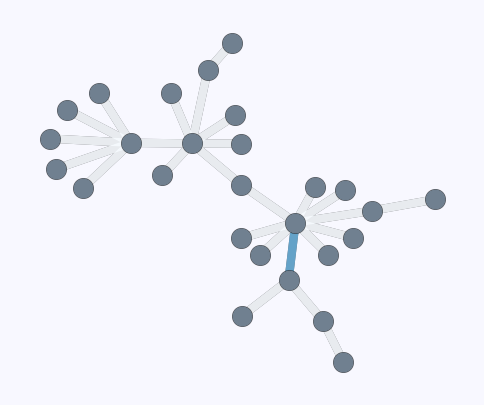

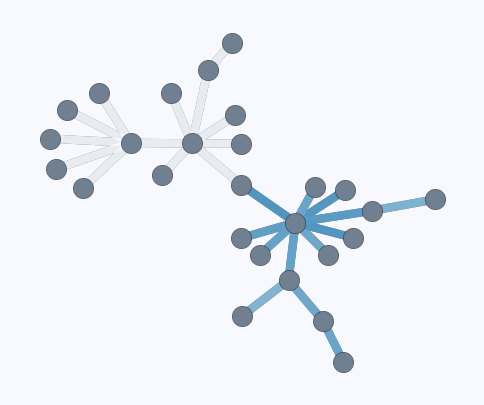

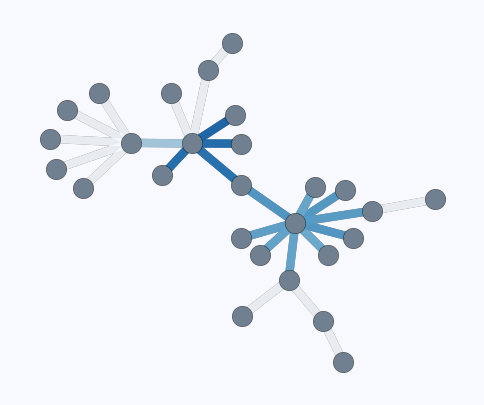

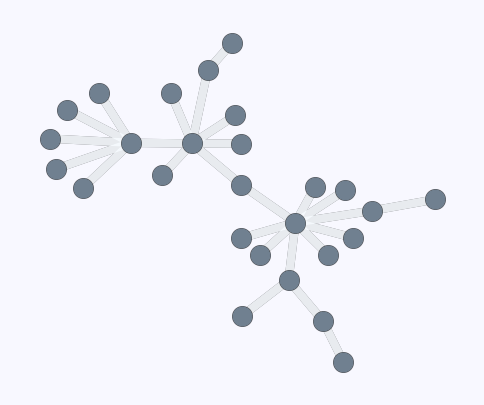

In [17]:
edge_colors_list = [edge_colors_0, edge_colors_1, edge_colors_2,edge_colors_3]
for i in range(4):
    fig, ax = plt.subplots(1, figsize=(6, 5))
    nx.draw_networkx(base_problem.context_graph, pos, with_labels=False, node_size=node_size, node_color='black', 
                 width=6, alpha=0.6, ax=ax)
    ec = nx.draw_networkx_edges(g, pos, edgelist=edges, alpha=0.9, width=6, edge_color=edge_colors_list[i], 
                                edge_vmin=0, edge_vmax=1, edge_cmap=mpl.colormaps['Blues'], ax=ax)
    nc = nx.draw_networkx_nodes(g, pos, nodelist=nodes, node_color='slategray', node_size=node_size*0.9, alpha=1, ax=ax)
    ax.set_axis_off()
    #ax.set_facecolor("yellow")
    fig.set_facecolor('ghostwhite')
    plt.savefig(f"experiment_figs/Intro{i+1}.svg", bbox_inches='tight')
    plt.show()

/tmp/ipykernel_846/1099759957.py:5: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  ec1 = nx.draw_networkx_edges(g, pos, edgelist=edges, alpha=0.9, width=6,


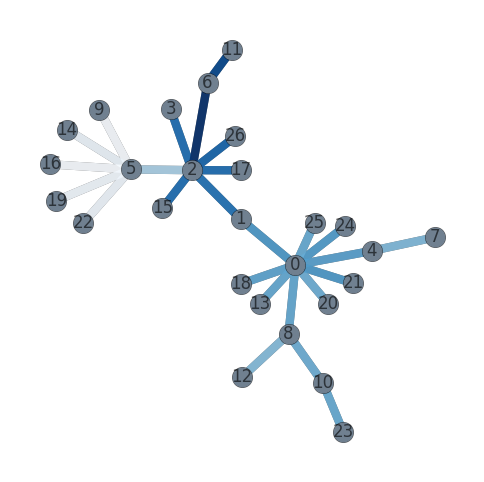

In [13]:
plt.figure(figsize=[6, 6])
nx.draw_networkx(base_problem.context_graph, pos, with_labels=True, node_size=node_size, node_color='black', 
                 width=6, alpha=0.6)
#ec = nx.draw_networkx_edges(g, pos, edgelist=edges, alpha=0.9, width=6, edge_color=edge_colors, edge_cmap=mpl.colormaps['Blues'], )
ec1 = nx.draw_networkx_edges(g, pos, edgelist=edges, alpha=0.9, width=6,
                            edge_color=np.array(all_Y), edge_cmap=mpl.colormaps['Blues'])
nc = nx.draw_networkx_nodes(g, pos, nodelist=nodes, node_color='slategray', node_size=node_size*0.9, alpha=1)

#plt.colorbar(ec)
plt.axis('off')
#plt.savefig(f"experiment_figs/Demo.pdf", bbox_inches='tight')
plt.show()